<h2><b><FONT COLOR="#6F8FAF"> 1. Import Required Libraries</b></h2>

In [ ]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Scikit-learn utilities
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_curve, auc,
                              RocCurveDisplay, precision_recall_curve)

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")


All libraries imported successfully.


<h2><b><FONT COLOR="#6F8FAF">  2. Load the Dataset</b></h2>

We load the Breast Cancer Wisconsin (Diagnostic) dataset and convert it into a Pandas DataFrame for easier exploration.
The target variable is binary:
- `0` = Malignant
- `1` = Benign


In [ ]:
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
# Target class names
print("Target classes:", dict(enumerate(data.target_names)))

# Basic info
df.info()


Target classes: {0: np.str_('malignant'), 1: np.str_('benign')}
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error      

<h2><b><FONT COLOR="#6F8FAF">  3. Exploratory Data Analysis (EDA)</b></h2>

Before building any model, we explore the dataset to understand its structure, check for missing values,
look at the distribution of the target class, and examine relationships between features.


In [ ]:
# Statistical summary
df.describe().T


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


<h2><b><FONT COLOR="#6F8FAF">  3.1 Class Distribution</b></h2>

It is important to check whether the dataset is balanced or imbalanced, since this affects
how we interpret accuracy vs. precision/recall.


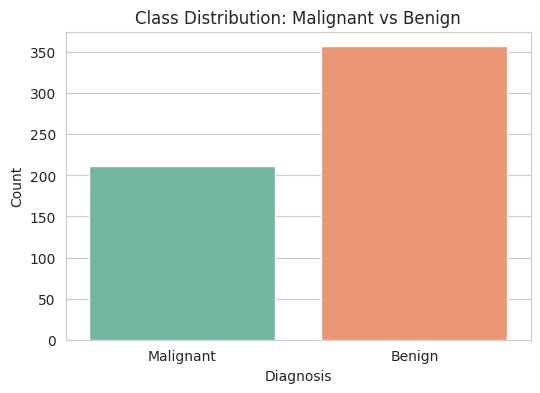

target
1    357
0    212
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['target'].map({0:'Malignant', 1:'Benign'}), palette='Set2')
plt.title('Class Distribution: Malignant vs Benign')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()

print(df['target'].value_counts())


<h2><b><FONT COLOR="#6F8FAF">  3.2 Correlation Heatmap</b></h2>

Visualizing correlation among a subset of key features helps identify multicollinearity.

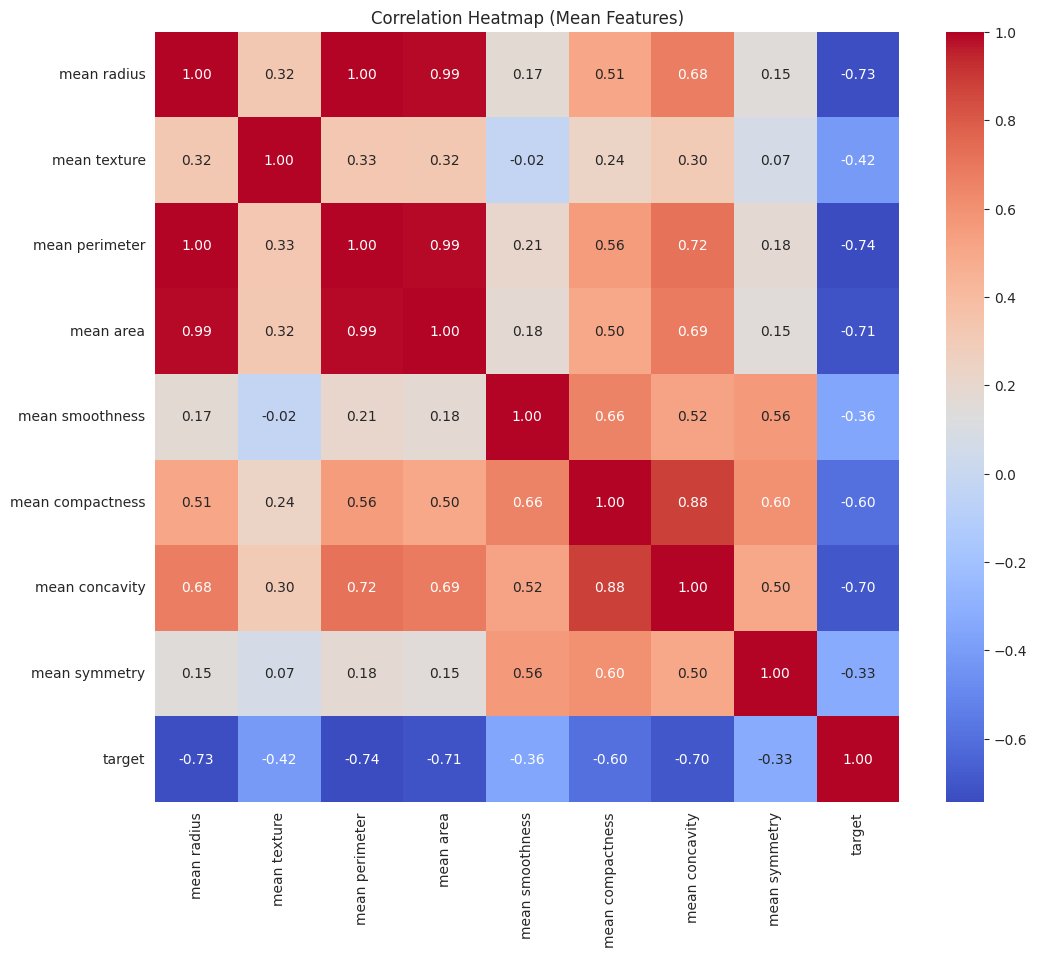

In [ ]:
plt.figure(figsize=(12,10))
key_features = ['mean radius','mean texture','mean perimeter','mean area',
                 'mean smoothness','mean compactness','mean concavity',
                 'mean symmetry','target']
sns.heatmap(df[key_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Mean Features)')
plt.show()


<h2><b><FONT COLOR="#6F8FAF">  3.3 Feature Distribution by Class</b></h2>

Boxplots showing how a few important features differ between malignant and benign tumors.

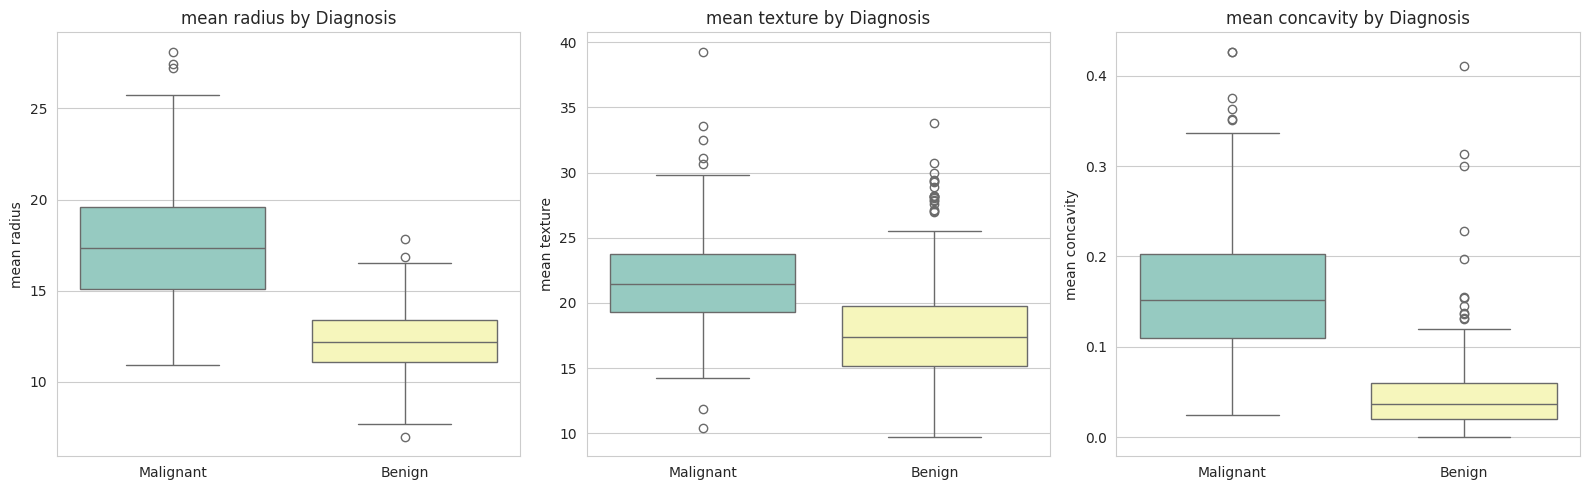

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))
for ax, feature in zip(axes, ['mean radius', 'mean texture', 'mean concavity']):
    sns.boxplot(x=df['target'].map({0:'Malignant',1:'Benign'}), y=df[feature], ax=ax, palette='Set3')
    ax.set_title(f'{feature} by Diagnosis')
    ax.set_xlabel('')
plt.tight_layout()
plt.show()


<h2><b><FONT COLOR="#6F8FAF">  4. Data Preprocessing </font></b></h2>

Steps performed:
1. Separate features (X) and target (y).
2. Split into training and testing sets (80/20 split, stratified to preserve class balance).
3. Apply feature scaling using `StandardScaler`. Scaling is **essential for KNN** (distance-based) and also
   helps Logistic Regression converge faster and produce more interpretable coefficients.


In [ ]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size :", X_test.shape)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling applied using StandardScaler (mean=0, std=1).")


Training set size: (455, 30)
Testing set size : (114, 30)

Feature scaling applied using StandardScaler (mean=0, std=1).


<h2><b><FONT COLOR="#6F8FAF"> 5. Train Logistic Regression Classifier </font></b></h2>

Logistic Regression is a linear model that estimates the probability of a sample belonging to a class
using the sigmoid function. We train it on the **scaled** training data.


In [ ]:
log_reg = LogisticRegression(max_iter=10000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression trained successfully.")


Logistic Regression trained successfully.


<h2><b><FONT COLOR="#6F8FAF">  6. Train K-Nearest Neighbors (KNN) Classifier</font></b></h2>

KNN classifies a sample based on the majority class among its 'k' nearest neighbors in feature space.
We start with a default value of k=5, and later (in the self-learning section) tune it properly.


In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]

print("KNN (k=5) trained successfully.")


KNN (k=5) trained successfully.


<h2><b><FONT COLOR="#6F8FAF">  7. Model Evaluation</font></b></h2>

We evaluate both classifiers using:
- **Accuracy** — overall correctness
- **Precision** — of predicted positives, how many are truly positive
- **Recall (Sensitivity)** — of actual positives, how many were correctly identified
- **F1 Score** — harmonic mean of precision and recall
- **Confusion Matrix** — breakdown of TP, TN, FP, FN


In [ ]:
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}\n")
    print(classification_report(y_true, y_pred, target_names=data.target_names))
    return acc, prec, rec, f1

lr_metrics = evaluate_model("Logistic Regression", y_test, y_pred_lr)
knn_metrics = evaluate_model("K-Nearest Neighbors", y_test, y_pred_knn)


--- Logistic Regression ---
Accuracy  : 0.9825
Precision : 0.9861
Recall    : 0.9861
F1 Score  : 0.9861

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

--- K-Nearest Neighbors ---
Accuracy  : 0.9561
Precision : 0.9589
Recall    : 0.9722
F1 Score  : 0.9655

              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



<h2><b><FONT COLOR="#6F8FAF">  7.1 Confusion Matrices </font></b></h2>

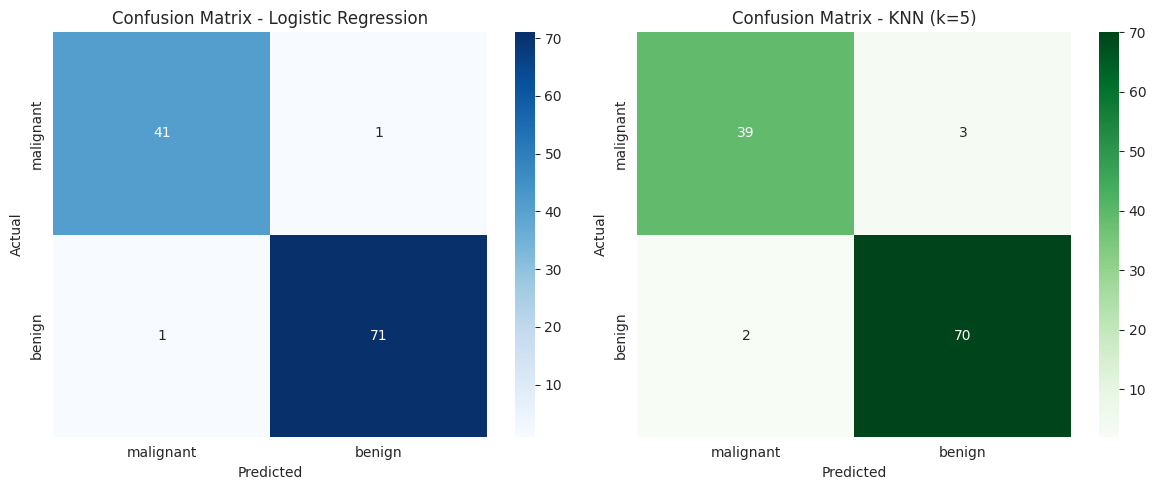

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names, yticklabels=data.target_names, ax=axes[0])
axes[0].set_title('Confusion Matrix - Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens',
            xticklabels=data.target_names, yticklabels=data.target_names, ax=axes[1])
axes[1].set_title('Confusion Matrix - KNN (k=5)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()


<h2><b><FONT COLOR="#6F8FAF">  8. Comparison Table</font></b></h2>

In [ ]:
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Logistic Regression': lr_metrics,
    'KNN (k=5)': knn_metrics
})
comparison_df


,Metric,Logistic Regression,KNN (k=5)
0,Accuracy,0.982456,0.956140
1,Precision,0.986111,0.958904
2,Recall,0.986111,0.972222
3,F1 Score,0.986111,0.965517


<h2><b><FONT COLOR="#6F8FAF">  8.1 Bar Chart Comparison of Metrics</font></b></h2>

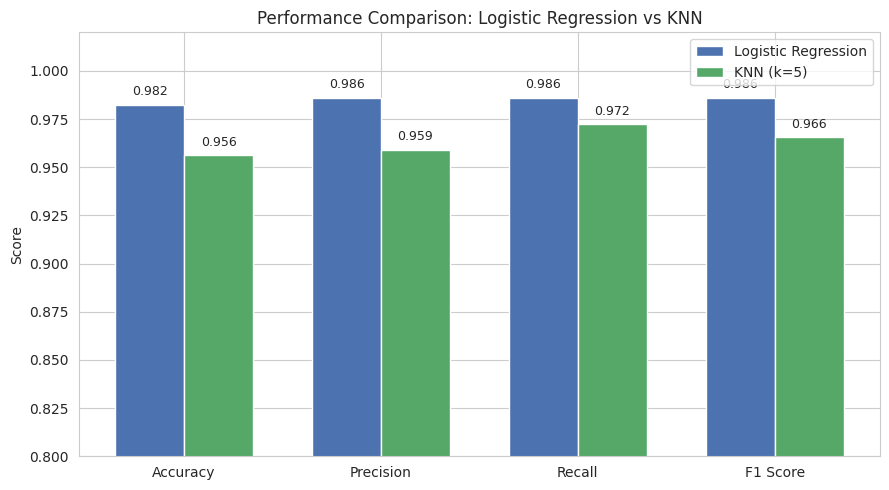

In [ ]:
metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9,5))
ax.bar(x - width/2, lr_metrics, width, label='Logistic Regression', color='#4C72B0')
ax.bar(x + width/2, knn_metrics, width, label='KNN (k=5)', color='#55A868')

ax.set_ylabel('Score')
ax.set_title('Performance Comparison: Logistic Regression vs KNN')
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.set_ylim(0.8, 1.02)
ax.legend()

for i, (lr_val, knn_val) in enumerate(zip(lr_metrics, knn_metrics)):
    ax.text(i - width/2, lr_val + 0.005, f'{lr_val:.3f}', ha='center', fontsize=9)
    ax.text(i + width/2, knn_val + 0.005, f'{knn_val:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


<h2><b><FONT COLOR="#6F8FAF">  9. Interpretation</font></b></h2>

- Compare the accuracy, precision, recall, and F1-score values obtained above.
- In medical diagnosis tasks such as this one, **Recall for the "Malignant" class** is particularly important,
  since a false negative (missing a malignant tumor) is far more costly than a false positive.
- Generally, on the Breast Cancer Wisconsin dataset, **Logistic Regression tends to perform slightly better or
  comparably to KNN**, because the classes are close to linearly separable in the (scaled) feature space, and
  Logistic Regression is less sensitive to the curse of dimensionality with 30 features.
- KNN's performance is highly sensitive to the choice of `k` and to feature scaling (explored further below).



<h2><b><FONT COLOR="#00008B">  Self-Learning Extensions </Font></h2></b>

The following five concepts go beyond what was asked in the lab and are included for deeper, independent
understanding of model evaluation and classifier behavior.

1. **K-Fold Cross-Validation** — more robust performance estimate than a single train/test split.
2. **Hyperparameter Tuning with GridSearchCV** — systematically finding the best `k` for KNN and the best
   regularization strength `C` for Logistic Regression.
3. **ROC Curve & AUC Score** — evaluating classifiers across all possible decision thresholds, not just 0.5.
4. **Effect of Feature Scaling on KNN** — demonstrating why scaling matters for distance-based algorithms.
5. **Decision Boundary Visualization using PCA** — projecting the 30-dimensional data into 2D to visually see
   how each classifier separates the classes.


<h2><b><FONT COLOR="#6F8FAF">  10.1 K-Fold Cross-Validation</font></b></h2>

A single train/test split can give a misleadingly optimistic or pessimistic performance estimate depending on
which samples end up in the test set. **K-Fold Cross-Validation** splits the data into `k` folds, trains on
`k-1` folds and tests on the remaining fold, repeating this `k` times and averaging the results — giving a
more reliable estimate of generalization performance.


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_cv_scores = cross_val_score(LogisticRegression(max_iter=10000), scaler.fit_transform(X), y, cv=cv, scoring='accuracy')
knn_cv_scores = cross_val_score(KNeighborsClassifier(n_neighbors=5), scaler.fit_transform(X), y, cv=cv, scoring='accuracy')

print("Logistic Regression 5-Fold CV Accuracy Scores:", np.round(lr_cv_scores, 4))
print(f"Mean: {lr_cv_scores.mean():.4f}  |  Std: {lr_cv_scores.std():.4f}\n")

print("KNN 5-Fold CV Accuracy Scores:", np.round(knn_cv_scores, 4))
print(f"Mean: {knn_cv_scores.mean():.4f}  |  Std: {knn_cv_scores.std():.4f}")



Logistic Regression 5-Fold CV Accuracy Scores: [0.9737 0.9474 0.9649 0.9912 0.9912]
Mean: 0.9737  |  Std: 0.0166

KNN 5-Fold CV Accuracy Scores: [0.9825 0.9561 0.9474 0.9825 0.9646]
Mean: 0.9666  |  Std: 0.0140


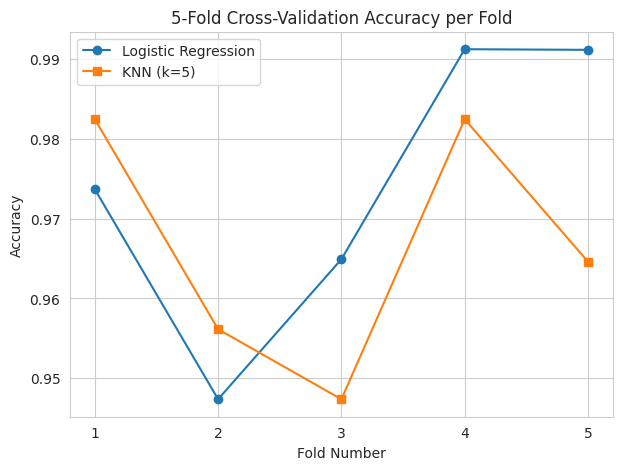

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(range(1,6), lr_cv_scores, marker='o', label='Logistic Regression')
plt.plot(range(1,6), knn_cv_scores, marker='s', label='KNN (k=5)')
plt.xlabel('Fold Number')
plt.ylabel('Accuracy')
plt.title('5-Fold Cross-Validation Accuracy per Fold')
plt.xticks(range(1,6))
plt.legend()
plt.show()


<h2><b><FONT COLOR="#6F8FAF"> 10.2 Hyperparameter Tuning with GridSearchCV
</font></b></h2>
Model performance depends heavily on hyperparameters:
- For KNN, the number of neighbors `k` controls the bias-variance tradeoff (small k = low bias/high variance).
- For Logistic Regression, the regularization strength `C` controls how much the model is penalized for
  large coefficients (smaller C = stronger regularization).

`GridSearchCV` automatically searches over a grid of hyperparameter values using cross-validation to find the
best combination.


Best k for KNN: 8
Best CV F1 Score: 0.9775


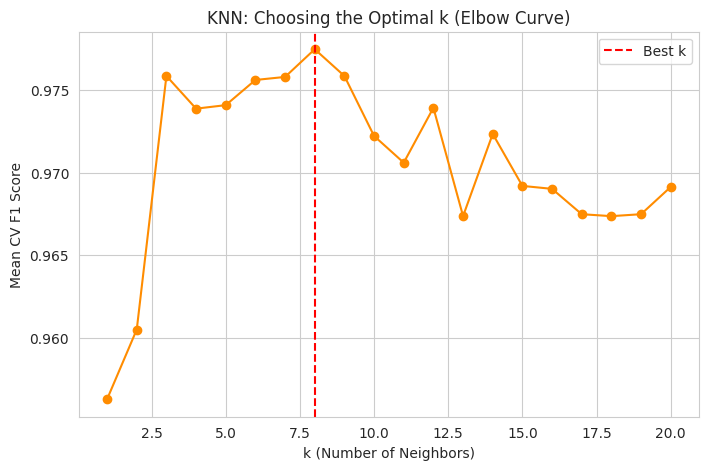

In [ ]:
# Tune KNN's k
param_grid_knn = {'n_neighbors': list(range(1, 21))}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring='f1')
grid_knn.fit(X_train_scaled, y_train)

print("Best k for KNN:", grid_knn.best_params_['n_neighbors'])
print("Best CV F1 Score:", round(grid_knn.best_score_, 4))

# Elbow-style plot of k vs CV score
results_knn = pd.DataFrame(grid_knn.cv_results_)
plt.figure(figsize=(8,5))
plt.plot(param_grid_knn['n_neighbors'], results_knn['mean_test_score'], marker='o', color='darkorange')
plt.axvline(grid_knn.best_params_['n_neighbors'], color='red', linestyle='--', label='Best k')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Mean CV F1 Score')
plt.title('KNN: Choosing the Optimal k (Elbow Curve)')
plt.legend()
plt.show()


In [ ]:
# Tune Logistic Regression's C
param_grid_lr = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
grid_lr = GridSearchCV(LogisticRegression(max_iter=10000), param_grid_lr, cv=5, scoring='f1')
grid_lr.fit(X_train_scaled, y_train)

print("Best C for Logistic Regression:", grid_lr.best_params_['C'])
print("Best CV F1 Score:", round(grid_lr.best_score_, 4))

# Re-evaluate tuned models on the test set
best_knn = grid_knn.best_estimator_
best_lr = grid_lr.best_estimator_

y_pred_best_knn = best_knn.predict(X_test_scaled)
y_pred_best_lr = best_lr.predict(X_test_scaled)

print("\nTuned KNN Test Accuracy:", round(accuracy_score(y_test, y_pred_best_knn), 4))
print("Tuned Logistic Regression Test Accuracy:", round(accuracy_score(y_test, y_pred_best_lr), 4))


Best C for Logistic Regression: 0.1
Best CV F1 Score: 0.9845

Tuned KNN Test Accuracy: 0.9737
Tuned Logistic Regression Test Accuracy: 0.9737


<h2><b><FONT COLOR="#6F8FAF"> 10.3 ROC Curve and AUC Score
</Font></h2></b>
A confusion matrix only reflects performance at a single decision threshold (usually 0.5). The **ROC (Receiver
Operating Characteristic) curve** plots the True Positive Rate against the False Positive Rate across *all*
thresholds, and the **AUC (Area Under Curve)** summarizes overall separability — closer to 1.0 is better.


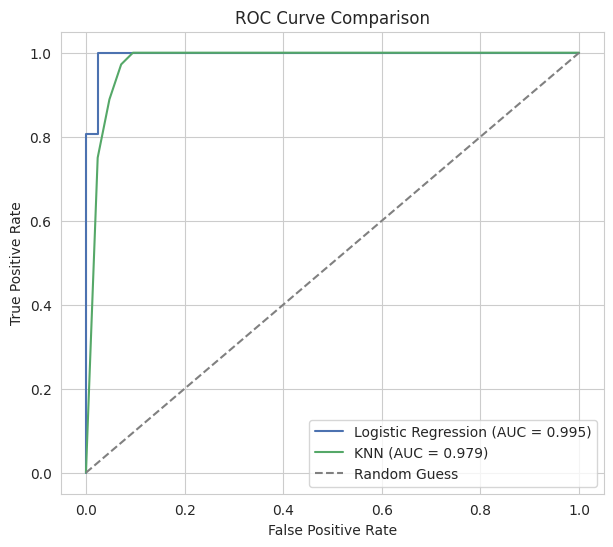

AUC - Logistic Regression: 0.9954
AUC - KNN: 0.9788


In [ ]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)

auc_lr = auc(fpr_lr, tpr_lr)
auc_knn = auc(fpr_knn, tpr_knn)

plt.figure(figsize=(7,6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})', color='#4C72B0')
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.3f})', color='#55A868')
plt.plot([0,1],[0,1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

print(f"AUC - Logistic Regression: {auc_lr:.4f}")
print(f"AUC - KNN: {auc_knn:.4f}")


<h2><b><FONT COLOR="#6F8FAF"> 10.4 Effect of Feature Scaling on KNN</Font></h2></b>

KNN relies on distance calculations, so features with larger numeric ranges (e.g., "mean area") can dominate
the distance metric over features with smaller ranges (e.g., "mean smoothness") if data is not scaled. This
experiment trains KNN on **unscaled** vs **scaled** data to demonstrate the impact.


KNN Accuracy WITHOUT scaling: 0.9123
KNN Accuracy WITH scaling   : 0.9561


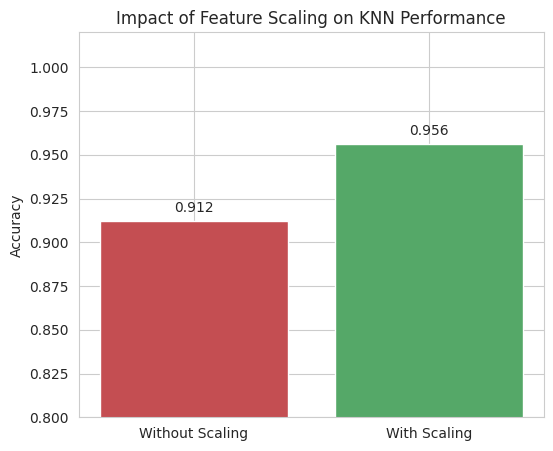

In [ ]:
# KNN on unscaled data
knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(X_train, y_train)
y_pred_unscaled = knn_unscaled.predict(X_test)
acc_unscaled = accuracy_score(y_test, y_pred_unscaled)

# KNN on scaled data (already trained above as `knn`)
acc_scaled = accuracy_score(y_test, y_pred_knn)

print(f"KNN Accuracy WITHOUT scaling: {acc_unscaled:.4f}")
print(f"KNN Accuracy WITH scaling   : {acc_scaled:.4f}")

plt.figure(figsize=(6,5))
bars = plt.bar(['Without Scaling', 'With Scaling'], [acc_unscaled, acc_scaled], color=['#C44E52', '#55A868'])
plt.ylabel('Accuracy')
plt.title('Impact of Feature Scaling on KNN Performance')
plt.ylim(0.8, 1.02)
for bar, val in zip(bars, [acc_unscaled, acc_scaled]):
    plt.text(bar.get_x()+bar.get_width()/2, val+0.005, f'{val:.3f}', ha='center')
plt.show()


<h2><b><FONT COLOR="#6F8FAF"> 10.5 Decision Boundary Visualization using PCA
</Font></h2></b>
The dataset has 30 features, which cannot be visualized directly. Using Principal Component Analysis (PCA),
we reduce the data to its top 2 principal components (capturing most of the variance) and visualize how each
classifier separates the two classes in this 2D space.


Variance explained by 2 components: 63.36%


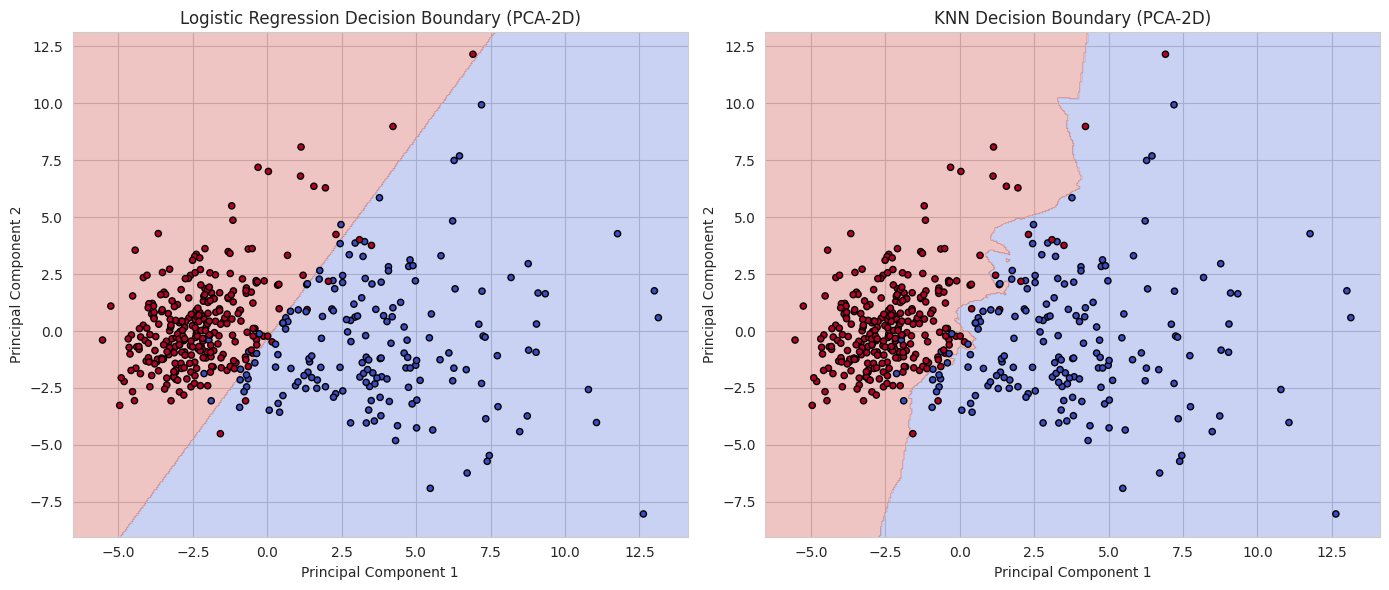

In [ ]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Variance explained by 2 components: {pca.explained_variance_ratio_.sum():.2%}")

# Retrain simple models on 2D PCA data purely for visualization purposes
lr_pca = LogisticRegression(max_iter=10000).fit(X_train_pca, y_train)
knn_pca = KNeighborsClassifier(n_neighbors=5).fit(X_train_pca, y_train)

def plot_decision_boundary(model, X, y, ax, title):
    h = 0.05
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    scatter = ax.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolor='k', s=20)
    ax.set_title(title)
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')

fig, axes = plt.subplots(1, 2, figsize=(14,6))
plot_decision_boundary(lr_pca, X_train_pca, y_train.values, axes[0], 'Logistic Regression Decision Boundary (PCA-2D)')
plot_decision_boundary(knn_pca, X_train_pca, y_train.values, axes[1], 'KNN Decision Boundary (PCA-2D)')
plt.tight_layout()
plt.show()

<h2><b><FONT COLOR="#6F8FAF"> Observation </Font></h2></b>

- Logistic Regression produces a **smooth, linear (straight-line) decision boundary**, since it models a linear
  combination of features passed through a sigmoid function.
- KNN produces a more **flexible, non-linear, jagged decision boundary**, since it relies purely on local
  neighborhoods rather than a global linear equation. This can capture more complex patterns but also makes it
  more prone to overfitting, especially with a small `k`.


<h2><b><FONT COLOR="#6F8FAF"> Final Summary and Conclusion </Font></h2></b>

| Aspect | Logistic Regression | KNN |
|---|---|---|
| Model type | Parametric, linear | Non-parametric, instance-based |
| Training time | Fast | Very fast (lazy learner, no real "training") |
| Prediction time | Fast | Slower (computes distances at prediction time) |
| Sensitive to feature scaling | Moderately | Highly |
| Interpretability | High (coefficients) | Low |
| Decision boundary | Linear | Non-linear / flexible |
| Key hyperparameter | Regularization strength `C` | Number of neighbors `k` |

**Conclusion:** Based on the accuracy, precision, recall, F1-score, and AUC values obtained in this experiment,
students should state which classifier performed better on the Breast Cancer Wisconsin dataset for their
specific run, and justify it using the metrics table and ROC curve above. In general, for this dataset, both
classifiers tend to achieve high performance (typically >95% accuracy) after proper scaling, with Logistic
Regression often having a slight edge in recall for the malignant class — which is the more clinically important
metric.
